In [6]:
# Install dependencies on colab
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

OSError: [Errno 107] Transport endpoint is not connected: '/content/gdrive/My Drive'

In [7]:
# Connect to google drive to load images and save model
from google.colab import drive
drive.mount('/content/drive')

path = Path('/content/gdrive/MyDrive/3rd_Year/ENDG_411/Assignment_3/gestures')
path.ls()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'Path' is not defined

In [8]:
ims = get_image_files(path)
ims

NameError: name 'get_image_files' is not defined

In [62]:
from fastai.vision.all import *

# 1. Data loading and augmentation

Create a DataBlock and DataLoaders using:
- Training and validation images collected in a2
- Use `set_seed()` to obtain reproducible results.
- Use `item_tfms` and/or `batch_tfms`. Set `min_scale` so that gestures are still visible
- Use a batch size of 32

Show a training and a validation batch.
Show augmentations, i.e. `show_batch()` with `unique=True`.

In [79]:
from fastbook import * #get image_files_sorted
gestures = DataBlock(
    blocks=(ImageBlock, CategoryBlock), #image->discrete category
    get_items=get_image_files_sorted, # path->images
    splitter=GrandparentSplitter(train_name='train', valid_name='test'), #how to train-valid split
    get_y=parent_label, # get the label from the directory name
    item_tfms=RandomResizedCrop(224, min_scale=1), # random crop at each iteration, resize to 224x224
    batch_tfms=aug_transforms()) #a set of transformations like  rotation, flipping, perspective warping, brightness changes and contrast changes

set_seed=set_seed(reproducible=True, s=7) #make results reproducible

dls = gestures.dataloaders(path, bs=32)

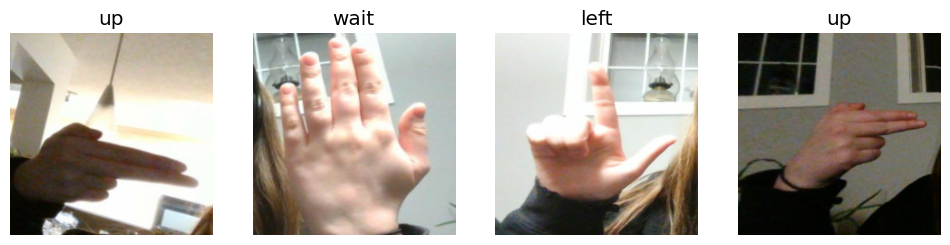

In [80]:
dls.train.show_batch(max_n=4, nrows=1)

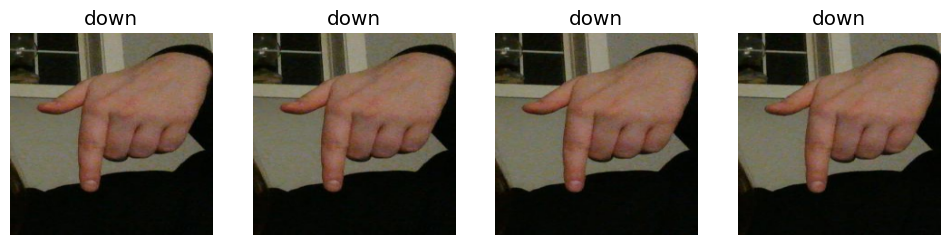

In [81]:
dls.valid.show_batch(max_n=4, nrows=1)

### Question 1: What type of item and batch transforms did you use? Can you spot any problems in the training set augmentations, e.g. gestures not visible?
Some of the gestures were not visible because I originally had min_scale set to 0.5. Then I saw some gestures were getting cut off so I changed min_scale to 1.


# 2. Train the classifier

## 2.1 Impact of learning rate
With:
- Same `set_seed()` as above
- Re-creating the same DataLoaders as above
- ResNet18 architecture.
- error rate as metric.

Use three learning rates:
- small: 3e-5
- medium: 3e-3
- large: 1e-1

Train the model with each learning rate using `fine_tune` with 10-15 epochs


In [ ]:
from fastbook import * #get image_files_sorted
gestures = DataBlock(
    blocks=(ImageBlock, CategoryBlock), #image->discrete category
    get_items=get_image_files_sorted, # path->images
    splitter=GrandparentSplitter(train_name='train', valid_name='test'), #how to train-valid split
    get_y=parent_label, # get the label from the directory name
    item_tfms=RandomResizedCrop(224, min_scale=1), # random crop at each iteration, resize to 224x224
    batch_tfms=aug_transforms()) #a set of transformations like  rotation, flipping, perspective warping, brightness changes and contrast changes

set_seed=set_seed(reproducible=True, s=7) #make results reproducible

dls = gestures.dataloaders(path, bs=32)



In [1]:
lrs = {'small': 3e-5, 'medium': 3e-3, 'large': 1e-1} # define the learning rates

# Train the model with each learning rate
for name, lr in lrs.items():
    print(f"Training with {name} learning rate: {lr}")

    learn = vision_learner(dls, resnet18, metrics=error_rate) # reset weights each time
    learn.fine_tune(12, lr) # set epochs and learning rate

    print(f"Results for {name} learning rate:") # Show results
    learn.recorder.plot_loss()


Training with small learning rate: 3e-05


NameError: name 'vision_learner' is not defined

### Question 2: Which training run resulted in the best model? State number of epochs and final error rate values for all learning rates and identify the best model.
*YOUR ANSWER HERE*


### Question 3: Did any models overfit? Include your reasoning.
*YOUR ANSWER HERE*


# 3. Analyze model performance
- Retrain the best model from above.
- Plot the confusion matrix.
- Plot 10 top losses

### Question 4: With which gestures does your model have the most problems with?
*YOUR ANSWER HERE*


# 4. Save the best model to file
Save the model using `learn.export()` as `.pkl` file. Verify that the model can be reloaded and used to make predictions.

# 5. Summary and Conclusion

Summarize the best model:
- Training strategy: learning rate and epochs used.
- Error rate achieved, summary of confusion matrix, i.e. what kind of errors does the model make.

*YOUR ANSWER HERE*


Conclusion:
- Are you satisfied with model performance? Why, why not?

*YOUR ANSWER HERE*


# 6.Reflection
Include a sentence or two about
- what you liked or disliked,
- found interesting, confusing, challangeing, motivating

while working on this assignment.

*YOUR ANSWER HERE*
